In [22]:
"""
数据源：大模型课程：第一阶段《基础入门》|默认班级
第 16课：准备数据集Data Loader
"""

# ---------------------------------- 1/ Prepare hyper parametres -------------------------

import torch
batch_size = 4
context_length = 16
d_model = 512
num_heads = 8
device = "cuda" if torch.cuda.is_available() else "cpu"


# ---------------------------------- 2/ Prepare dataset ----------------------------------

# # prepare  are data  from huggingface
# import os
# import requests
# if not os.path.exists("some_data.txt"):
#     download_url = ""
#     with open("some_data.txt", "w") as f:
#         f.write(requests.get(download_url).text)

with open("L:\\AI\\OpenAIProject\\AGI11_Transformer\\some_data.txt", "r") as f:
    text = f.read()     # 读取文本，原始数据保持不变
    # print(text)
    print(text[:1000])
    print('\n')
    print('该TEXT一共有：', len(text),'字')
    print('\n')


# ---------------------------------- 3/ Tokenization -------------------------------------

# # tokenization -- use tiktoken from OpenAI
# import tiktoken
# encoding = tiktoken.get_encoding('cl100k_base')
# tokenized_text = encoding.encode(text)
# # print('观察前10个token的编码：', tokenized_text[:10])
# # print('观察上面编码对应的文字/符号：', encoding.decode(tokenized_text[:10]))
# # 使用for循环显示每个token及其对应的编码
# for i, token in enumerate(tokenized_text[:10]):
#     print(f"Token {i+1}: 编码为 {token}, 对应的文字/符号为 '{encoding.decode([token])}'")

# # 对比文字、token和有效token数量
# print('\n')
# total_text = len(text)
# total_tokens = len(tokenized_text)
# vocab_size = len(set(tokenized_text))
# max_token = max(tokenized_text)
# print(f"总字数：{total_text/10000}万")
# print(f"总token数：{total_tokens/10000}万   备注：有的词被拆分为几个token，因而比总字数要多")
# print(f"总词数：{vocab_size}个token")
# print(f"最大token编码：{max_token}")
# print('\n')

{"Instruction": "请以一种合适的文风与内容逻辑扩写给你的文本", "Input": "花千骨的父亲花秀才病危,临死交代花千骨去茅山学艺以免妖魔缠身。花千骨十分沮丧,她生来就无泪之体,即便伤心也流不出泪水。花秀才一生悉心教导花千骨独立坚强。花秀才去世后,村民和张大夫帮忙办理了简单的丧事。张大夫认为花千骨年幼,不宜外出,希望先收养她,治愈她腿上的伤。花千骨坚持要遵从父命去茅山。张大夫无奈,协助她变卖家里值钱之物,资助她银两。夜晚,花千骨独自一人躺在空房,听着外边狼嚎,脑中满是悲伤和迷茫。次日清早,她告别村民出发去茅山。", "Response": "天上没有星子，更没有月亮，漆黑得像一个大洞，让人有些颠倒分不清上下，似乎一失脚就要坠进去。\n“南无阿弥陀佛南无阿弥陀佛……”一个约莫十二三岁的小孩孤零零一个人在路上急速的走着。右手握着一小串佛珠碎碎的念，左手提着个油皮灯笼。\n与其说她是走不如说是在跑，因为那些东西一直在后面跟着她，只是因为佛珠的原因不敢太靠近。周围漆黑一片，只看得见灯笼荧荧鬼火一般在半空中飘移着。四野寂静得有些诡异，连流水声，虫鸣声都听不见。\n马上就要到村子里了，进了村就好了，小孩不断提醒自己，苍白着脸，冷汗直往下掉。腾出右手把身上披的八只黑狗皮拼制成的披风裹得更严实一点，妄图不让自己的气味更多的散发出去。\n可是走到村头的小石拱桥上，小孩还是傻那里了。一个打着纸伞的女人站在桥上正对着她，伞面上绣的是红得耀眼的桃花，白色的衣裙上也是。伞打得很低，看不见脸。明明是炎热酷闷得没有一点风，可是那裙袂却激荡的上下翻飞着。\n小孩吓得停在那里双腿直打颤，完了，遇上鬼拦路了。\n“南无阿弥陀佛……”她继续低声念着，侧过身子想从桥另一边过，低下头装作没看见她。却发现她眨眼间又站在了她的面前。精致的白色绣花鞋上沾满了泥，脚边是一滩的水，还有各种绿色的水藻和贝壳。这时她才看清，那裙摆上的哪是桃花，分明是溅染的鲜血。\n突然，手中灯笼本应该温柔的黄光开始诡异的从青色变成红色，好像也被血染过了一样。空气里满是刺鼻的河里的膻气与血的腥臭。\n“南无阿弥陀佛……”硬着头皮把佛珠举到前面，那女鬼退了两步，小孩又前进两步，那女鬼又退两步。快到桥头时，却听一阵令人毛骨悚然的笑声响起。\n咣的一下，面前的女鬼散裂了开来，肢体断作无数截，仿佛被硬生生砍碎一样，一地都是血和

In [23]:
# using  integer mapping 处理乱码
characters = sorted(list(set(text)))
print(f'观察前 几个字符 情况：{characters[:10]}')
print('一共有', len(characters),'从小排到大的不重复的字符')

i2s = {i:ch for i, ch in enumerate(characters)}
s2i = {ch:i for i, ch in enumerate(characters)}

def encode(texts):
    return [s2i[ch] for ch in texts] # 返回对应文字的编码/码号

def decode(integers):
    return ''.join([i2s[i] for  i in integers])

tokenized_text = encode(text)
max_token_value = max(tokenized_text) + 1
print(max_token_value)

观察前 几个字符 情况：['\n', ' ', '!', '"', '#', '%', '&', "'", '(', ')']
一共有 5821 从小排到大的不重复的字符
5821


In [24]:
#
tokenized_text = torch.tensor(tokenized_text, dtype=torch.long,  device=device)
print(f'观察前{len(tokenized_text[:10])}个token，分别是：{tokenized_text[:10]}')
print(tokenized_text.shape)
print('\n')


split_idx = int(0.8 * len(tokenized_text))
train_data = tokenized_text[:split_idx] # 80%的数据用于训练
val_data = tokenized_text[split_idx:]   # 20%的数据用于验证

# prepare x_batch, y_batch
idxs = torch.randint(low = 0, high = len(train_data) - context_length, size = (batch_size,))
x_batch = torch.stack([train_data[i:i+context_length] for i in idxs])
y_batch = torch.stack([train_data[i+1:i+context_length+1] for i in idxs])
print('x_batch未初始化的形状：', x_batch.shape, '\ny_batch未初始化的形状：', y_batch.shape)
print('\n')

import pandas as pd
print('Our x batch as below:(未初始化的值)')
print(pd.DataFrame(x_batch))
print('Our y batch as below:(未初始化的值)')
print(pd.DataFrame(y_batch))
print('\n')

token_embedding_lookup_table = torch.nn.Embedding(max_token_value + 1, d_model, device = device)
x = token_embedding_lookup_table(x_batch)
y = token_embedding_lookup_table(y_batch)
print('初始化的x,y的形状：', x.shape, y.shape)
print('\n')

print('Our x as below:(初始化的值),context length as row, dimension as column')
print(pd.DataFrame(x[0].detach().cpu().numpy()))


# ---------------------------------- 4/ Positional encoding  -----------------------------

# Positional encoding
import math
position_encoding_lookup_table = torch.zeros(context_length, d_model)  # 位置信息编码初始化为0
print('位置信息 初始化为0：', position_encoding_lookup_table)
position = torch.arange(0, context_length, dtype=torch.float).unsqueeze(1)
print('position:', position)

div_term = torch.exp((-math.log(10000.0) * torch.arange(0, d_model, 2, dtype=torch.float) / d_model))
position_encoding_lookup_table[:, 0::2] = torch.sin(position * div_term)
position_encoding_lookup_table[:, 1::2] = torch.cos(position * div_term)
# print('位置信息 初始化后的值：', position_encoding_lookup_table)
# print('\n')
print('Our position_encoding_lookup_table as below:')
print(pd.DataFrame(position_encoding_lookup_table.detach().cpu().numpy()))
print('\n')
print(position_encoding_lookup_table.shape)
position_encoding_lookup_table = position_encoding_lookup_table.unsqueeze(0).expand(batch_size, context_length, d_model)
print('Our position_encoding_lookup_table as below with batch size:', position_encoding_lookup_table.shape)
print('\n')

x = x + position_encoding_lookup_table
y= y + position_encoding_lookup_table

print('有了位置信息编码后的x:', x.shape, '\t\n', x)



观察前10个token，分别是：tensor([91,  3, 41, 78, 83, 84, 82, 85, 67, 84])
torch.Size([17184598])


x_batch未初始化的形状： torch.Size([4, 16]) 
y_batch未初始化的形状： torch.Size([4, 16])


Our x batch as below:(未初始化的值)
     0     1     2     3     4     5     6     7     8     9     10    11  \
0  3369  4040  4123  4678  4733   152  3719   706  3260   242   186  5135   
1  1380   593  1656  1653  1072  5809   674  2283   335  3262  3993   817   
2   144  2585  4894   308  5454  4879  5010  2361   288  5809   475  3788   
3  3487   252  5083   187   150  4673  5809  1893   268  3369  4733  4643   

     12    13    14    15  
0   152   288  3585  1629  
1   335  3262  2234  2735  
2   562  4082   152  4082  
3  1896  4653  4643  3861  
Our y batch as below:(未初始化的值)
     0     1     2     3     4     5     6     7     8     9     10    11  \
0  4040  4123  4678  4733   152  3719   706  3260   242   186  5135   152   
1   593  1656  1653  1072  5809   674  2283   335  3262  3993   817   335   
2  2585  4894   30

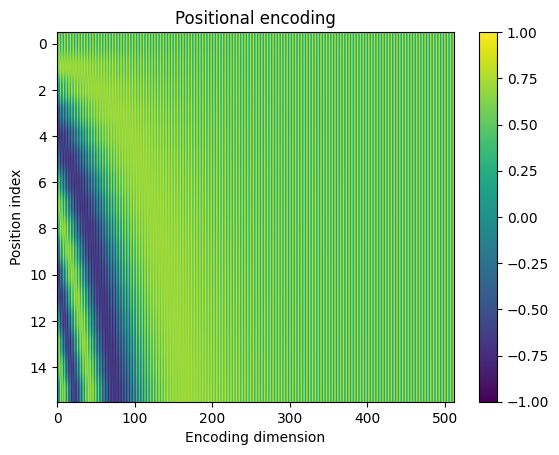

In [25]:
# 可视化 visualization
import matplotlib.pyplot as plot
def visualize_pe(pe):
    plot.imshow(pe, aspect='auto')
    plot.title('Positional encoding')
    plot.xlabel('Encoding dimension')
    plot.ylabel('Position index')
    plot.colorbar()
    plot.show
visualize_pe(position_encoding_lookup_table[0].cpu().numpy())   # 图形解读：越接近1表示越相似

In [26]:
import torch.nn as nn

Wq = nn.Linear(d_model, d_model)
Wk = nn.Linear(d_model, d_model)
Wv = nn.Linear(d_model, d_model)

Q = Wq(x)
K = Wk(x)
V = Wv(x)
print('Q,K,V的形状一样，分别是：', Q.shape, K.shape, V.shape)

Q,K,V的形状一样，分别是： torch.Size([4, 16, 512]) torch.Size([4, 16, 512]) torch.Size([4, 16, 512])


In [27]:
Q = Q.reshape(batch_size, context_length, num_heads, -1).permute(0,2,1,3)
K = K.reshape(batch_size, context_length, num_heads, -1).permute(0,2,1,3)
V = V.reshape(batch_size, context_length, num_heads, -1).permute(0,2,1,3)
print('QKV变换之后的形状一样，分别是 (batch+head+context length+dimension)', Q.shape, K.shape, V.shape)

QKV变换之后的形状一样，分别是 (batch+head+context length+dimension) torch.Size([4, 8, 16, 64]) torch.Size([4, 8, 16, 64]) torch.Size([4, 8, 16, 64])


In [28]:
 # Q @ K
attention = Q @ K.transpose(-2,-1)
print('\nAttention1 Q @ K形状：', attention.shape)
print(pd.DataFrame(attention[0][0].detach().cpu().numpy()))

# scale
attention = attention / math.sqrt(d_model // num_heads)
print('\n\nAttention2 Q @ K/sqrt(d_model//num_heads)形状：', attention.shape)
print('留意与上一步数据大小对比（变小了）\n', pd.DataFrame(attention[0][0].detach().cpu().numpy()))


Attention1 Q @ K形状： torch.Size([4, 8, 16, 16])
          0         1         2         3         4         5         6   \
0   1.953234  5.515649 -1.789201 -1.931798  1.200981 -2.555693  2.787382   
1  -0.344199  5.492159  0.987056 -1.181606 -3.719069 -0.257092  0.610875   
2  -1.543393  5.210670  9.301728  0.143273 -2.126660 -5.883517 -3.711254   
3  -0.643208  4.610505 -0.243065 -2.059667 -0.306595 -0.905659  3.520247   
4   2.874652  9.746428 -0.192513 -4.987399 -3.234997  0.511736  2.945642   
5  -2.456776  3.782492 -0.772030 -2.055538  0.293313  1.887329  2.542339   
6   0.043986  2.665109 -0.338017  0.343566  5.319977  0.422228  0.646608   
7   3.187732 -4.998912 -2.573902  0.893184  0.200027 -0.498656  3.703889   
8  -0.626789 -2.150843 -3.887872 -2.689066  1.452202 -1.675284 -3.990499   
9  -1.828017 -4.996308  0.329189  0.232697  0.771288 -6.890971 -4.762868   
10 -6.956949 -2.493068  2.766114 -2.184739 -4.068925 -1.028513 -2.283900   
11 -2.332767 -0.366025 -0.146179 -4.4241

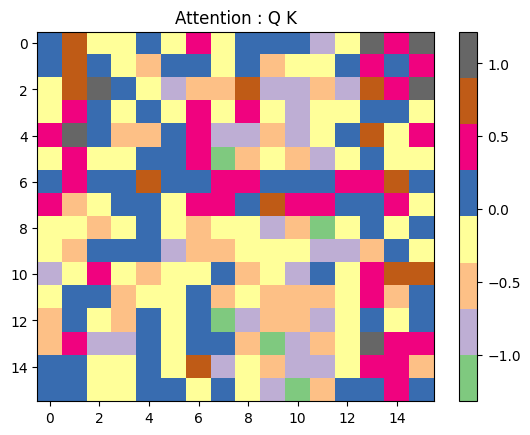

In [29]:
plot.imshow(attention[0][0].detach().cpu().numpy(),'Accent', aspect='auto')
plot.title('Attention : Q K')
plot.colorbar()

In [30]:
# Masking
mask = torch.ones(attention.shape[-2:])


In [31]:
print('初始化mask是1', mask)

初始化mask是1 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.,

In [32]:
mask = torch.triu(mask, diagonal=1)
mask

tensor([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0

In [33]:
mask = torch.triu(mask, diagonal=1).bool()
mask

tensor([[False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False,  True,  True,  True,
          True,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False,  True,  True,
    

In [34]:
 attention = attention.masked_fill(mask, float('-inf'))
print('Attention3 mask applied:\n', pd.DataFrame(attention[0][0].detach().cpu().numpy()))


Attention3 mask applied:
           0         1         2         3         4         5         6   \
0   0.244154      -inf      -inf      -inf      -inf      -inf      -inf   
1  -0.043025  0.686520      -inf      -inf      -inf      -inf      -inf   
2  -0.192924  0.651334  1.162716      -inf      -inf      -inf      -inf   
3  -0.080401  0.576313 -0.030383 -0.257458      -inf      -inf      -inf   
4   0.359331  1.218303 -0.024064 -0.623425 -0.404375      -inf      -inf   
5  -0.307097  0.472812 -0.096504 -0.256942  0.036664  0.235916      -inf   
6   0.005498  0.333139 -0.042252  0.042946  0.664997  0.052779  0.080826   
7   0.398466 -0.624864 -0.321738  0.111648  0.025003 -0.062332  0.462986   
8  -0.078349 -0.268855 -0.485984 -0.336133  0.181525 -0.209411 -0.498812   
9  -0.228502 -0.624538  0.041149  0.029087  0.096411 -0.861371 -0.595358   
10 -0.869619 -0.311634  0.345764 -0.273092 -0.508616 -0.128564 -0.285487   
11 -0.291596 -0.045753 -0.018272 -0.553024 -0.103745 -0.179134

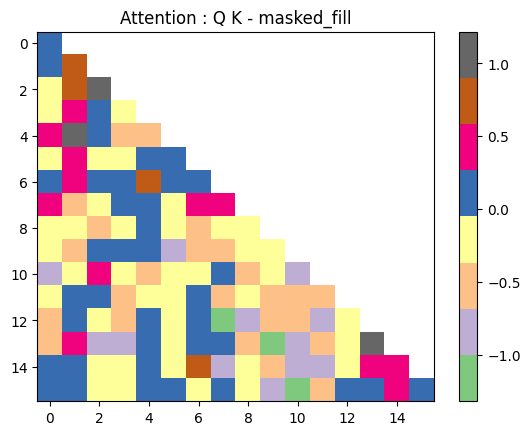

In [35]:
plot.imshow(attention[0][0].detach().cpu().numpy(),'Accent', aspect='auto')
plot.title('Attention : Q K - masked_fill')
plot.colorbar()

In [36]:
# Probabilities - softmax
attention = torch.softmax(attention, dim=-1)  # 对最后一个维度dim=-1进行softmax

print('Attention4 概率化softmax\n', pd.DataFrame(attention[0][0].detach().cpu().numpy()))   # [0][0] 第一个批次第一个头 


Attention4 概率化softmax
           0         1         2         3         4         5         6   \
0   1.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1   0.325295  0.674705  0.000000  0.000000  0.000000  0.000000  0.000000   
2   0.138783  0.322844  0.538373  0.000000  0.000000  0.000000  0.000000   
3   0.207578  0.400303  0.218225  0.173895  0.000000  0.000000  0.000000   
4   0.204814  0.483510  0.139589  0.076657  0.095430  0.000000  0.000000   
5   0.116299  0.253679  0.143560  0.122280  0.164009  0.200172  0.000000   
6   0.118488  0.164424  0.112963  0.123009  0.229134  0.124224  0.127758   
7   0.168056  0.060399  0.081785  0.126151  0.115681  0.106006  0.179256   
8   0.127665  0.105520  0.084926  0.098655  0.165552  0.111983  0.083843   
9   0.101815  0.068520  0.133327  0.131729  0.140903  0.054070  0.070549   
10  0.050077  0.087493  0.168840  0.090930  0.071849  0.105070  0.089810   
11  0.082160  0.105057  0.107984  0.063259  0.099138  0.091939  0

In [37]:
# @ V 回归最初形状
attention = attention @ V


In [38]:
print(f'Attention5 回归最初形状但还没合并{num_heads}个头\n', pd.DataFrame(attention[0][0].detach().cpu().numpy()))   # [0][0] 第一个批次第一个头 


Attention5 回归最初形状但还没合并8个头
           0         1         2         3         4         5         6   \
0  -0.563505  0.061775 -0.134904 -1.087779  0.743587  0.049355 -0.681534   
1  -0.433346 -0.349756  0.306355 -0.932109  0.629510  0.104350 -0.513596   
2  -0.419704 -0.135498  0.478682 -0.964030  1.017324 -0.072818 -0.479397   
3  -0.445245 -0.149668  0.419418 -0.962538  0.820150 -0.107321 -0.615997   
4  -0.375519 -0.274939  0.349302 -0.953559  0.704650 -0.058462 -0.515940   
5  -0.322942 -0.251738  0.530868 -0.746794  0.833727 -0.476471 -0.570082   
6  -0.070042 -0.271388  0.357204 -0.845367  0.798127 -0.346755 -0.449690   
7   0.063469 -0.133714  0.168470 -0.762531  0.943755 -0.370847 -0.340319   
8  -0.070909 -0.189997  0.212637 -0.721898  0.934039 -0.332568 -0.378979   
9  -0.080737 -0.214262  0.253042 -0.800639  0.976464 -0.295556 -0.384371   
10  0.021204 -0.181056  0.292053 -0.697390  1.117580 -0.345289 -0.348058   
11  0.044667 -0.164554  0.280000 -0.633275  1.078730 -0.29046

In [39]:
attention.shape

torch.Size([4, 8, 16, 64])

In [40]:
# concatenate heads
# A = attention.transpose(1,2)  # 把context_length和num_heads调换位置恢复成最初形状
# A.shape

In [41]:
A = attention.transpose(1,2).reshape(batch_size, context_length,-1)
print('把多个头合并成X未分头时形状：', A.shape)
print(f'Attention6 多头合并后回归最初形状 - 第一个批次第一个字的{d_model}维度\n', pd.DataFrame(A[0][0].detach().cpu().numpy()))   # [0][0] 第一个批次第一个字的d_model维度坐标系


把多个头合并成X未分头时形状： torch.Size([4, 16, 512])
Attention6 多头合并后回归最初形状 - 第一个批次第一个字的512维度
             0
0   -0.563505
1    0.061775
2   -0.134904
3   -1.087779
4    0.743587
..        ...
507  0.704093
508  0.282709
509 -0.585888
510  0.864431
511  0.717660

[512 rows x 1 columns]


In [42]:
# 这个部分没运行成功，待检查更正

# # Visualize attention score using BervViz
# from bertviz import head_view, model_view

# attention_weights_first_head = [attention[i].unsqueeze(0) for i in range(batch_size)]
# # print(attention_weights_first_head[0].shape) # torch.size[1,4,16,16]

# # Create a list of lists  for the tokens(requreid by head_view)
# tokens_list = [[decode([idx])] for idx in x_batch[2].tolist()]

# head_view(attention_weights_first_head, tokens_list, prettify_tokens=False)


In [43]:
Wo = nn.Linear(d_model, d_model)
output = Wo(A)

output.shape
print(f'某个token对应的{d_model}维度坐标系的位置:', A[0][2]) # 某个token对应的d_model坐标系的位置 ，第一个批次第三行所代表的token/文字

某个token对应的512维度坐标系的位置: tensor([-4.1970e-01, -1.3550e-01,  4.7868e-01, -9.6403e-01,  1.0173e+00,
        -7.2818e-02, -4.7940e-01, -5.0024e-01, -4.6535e-01, -4.6836e-02,
        -7.6863e-01,  5.4383e-01, -1.4890e-01,  4.9188e-01, -3.5790e-01,
         2.9465e-01,  5.7882e-01,  4.5292e-01, -1.9378e-01, -5.3654e-01,
         4.0893e-01,  4.7424e-01, -2.0590e-01, -7.6893e-01, -1.4676e+00,
         1.3626e-01, -5.4445e-02,  5.1449e-01,  9.0302e-01,  4.3952e-01,
         4.4873e-01, -3.1861e-01,  9.4333e-01, -3.5057e-01, -1.0506e+00,
        -2.2017e-01,  3.6293e-01, -2.8822e-02,  3.9890e-01, -1.7487e-01,
        -4.4678e-01,  1.1861e+00, -3.2809e-01,  6.2292e-01,  1.5207e-01,
         9.9122e-02,  3.5985e-01,  8.2722e-02, -3.3589e-02, -3.3929e-01,
        -5.2980e-01, -2.0636e-01,  4.7072e-01, -4.6662e-01, -1.7658e-01,
         3.9493e-01, -3.4442e-01,  4.9682e-01,  8.7797e-01,  6.0366e-01,
        -4.9082e-01,  2.0461e-01,  3.3411e-01, -1.8625e-01,  5.4410e-01,
         4.5432e-01, -5.4559

In [44]:
# 如何打印参数

for name, value in Wo.named_parameters():
    print(name, value.shape, value)

weight torch.Size([512, 512]) Parameter containing:
tensor([[ 0.0428, -0.0259,  0.0124,  ..., -0.0286,  0.0405, -0.0312],
        [-0.0345,  0.0436, -0.0204,  ..., -0.0210, -0.0396, -0.0210],
        [-0.0076, -0.0199,  0.0217,  ...,  0.0141,  0.0227, -0.0394],
        ...,
        [-0.0125, -0.0028,  0.0355,  ..., -0.0346, -0.0243, -0.0233],
        [-0.0295,  0.0092, -0.0040,  ...,  0.0246,  0.0036,  0.0369],
        [ 0.0275, -0.0193,  0.0396,  ...,  0.0240, -0.0033,  0.0094]],
       requires_grad=True)
bias torch.Size([512]) Parameter containing:
tensor([-2.7057e-02,  1.2096e-02, -1.3195e-02, -1.0327e-02,  2.5670e-02,
         2.5718e-02, -3.7683e-02,  2.0667e-02, -1.9782e-02,  2.9272e-02,
        -1.4626e-02,  1.0350e-02, -2.8020e-03, -1.0114e-03,  3.5591e-02,
         9.7813e-03, -3.2022e-02,  3.3489e-02, -9.8615e-03,  9.8457e-03,
        -3.4780e-02, -7.3209e-05,  5.1133e-03,  1.3899e-02, -1.7796e-02,
        -3.7913e-02, -1.9301e-02, -3.3334e-02, -1.8603e-02, -4.1497e-03,
    